In [2]:
# =========================
# DAY 6 - STEP 1: SETUP
# =========================

import pandas as pd
import numpy as np

# Load dataset (correct file name)
df = pd.read_csv("07_scheme_performance.csv")

# Quick preview to confirm data loaded correctly
df.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [5]:
# =========================
# STEP 2: SELECT RETURN COLUMN
# =========================

print("Dataset columns loaded successfully")

# We use 3-year return as base return for risk analysis
df["return"] = df["return_3yr_pct"]

# Check
df[["scheme_name", "return"]].head()

Dataset columns loaded successfully


,scheme_name,return
0,SBI Bluechip Fund - Regular Plan - Growth,12.36
1,SBI Bluechip Fund - Direct Plan - Growth,11.30
2,SBI Small Cap Fund - Regular Plan - Growth,23.39
3,SBI Small Cap Fund - Direct Plan - Growth,23.14
4,SBI Magnum Gilt Fund - Regular Plan - Growth,6.07


In [6]:
# =========================
# STEP 3: VaR & CVaR CALCULATION
# =========================

import numpy as np

# Function to compute VaR and CVaR
def compute_var_cvar(x, confidence=0.95):
    var = np.percentile(x, (1 - confidence) * 100)
    cvar = x[x <= var].mean()
    return var, cvar

# Store results
results = []

# Calculate per scheme
for scheme, data in df.groupby("scheme_name"):
    
    returns = data["return"].dropna()
    
    var, cvar = compute_var_cvar(returns)
    
    results.append({
        "scheme_name": scheme,
        "var_95": var,
        "cvar_95": cvar
    })

var_cvar_df = pd.DataFrame(results)

var_cvar_df.head()

,scheme_name,var_95,cvar_95
0,ABSL Frontline Equity Fund - Regular - Growth,13.78,13.78
1,ABSL Liquid Fund - Regular - Growth,5.14,5.14
2,ABSL Small Cap Fund - Regular - Growth,22.38,22.38
3,Axis Bluechip Fund - Direct - Growth,12.14,12.14
4,Axis Bluechip Fund - Regular - Growth,11.84,11.84


In [7]:
# =========================
# STEP 4: SAVE OUTPUT FILE
# =========================

# Save VaR & CVaR results
var_cvar_df.to_csv("var_cvar_report.csv", index=False)

print("File created successfully: var_cvar_report.csv")

File created successfully: var_cvar_report.csv


In [8]:
import os
os.listdir()

['.ipynb_checkpoints',
 '01_fund_master.csv',
 '02_nav_history.csv',
 '03_aum_by_fund_house.csv',
 '03_eda_analysis.ipynb',
 '04_monthly_sip_inflows.csv',
 '04_performance_analytics.ipynb',
 '05_category_inflows.csv',
 '06_industry_folio_count.csv',
 '07_scheme_performance.csv',
 '08_investor_transactions.csv',
 '09_portfolio_holdings.csv',
 '10_benchmark_indices.csv',
 'customer_shopping_behavior.csv',
 'Customer_Shopping_Behaviour_Analysis.ipynb',
 'Day6_Advanced_Analytics.ipynb',
 'Fake News Detection.ipynb',
 'Fake.csv',
 'mean-variance-calculator',
 'True.csv',
 'var_cvar_report.csv']

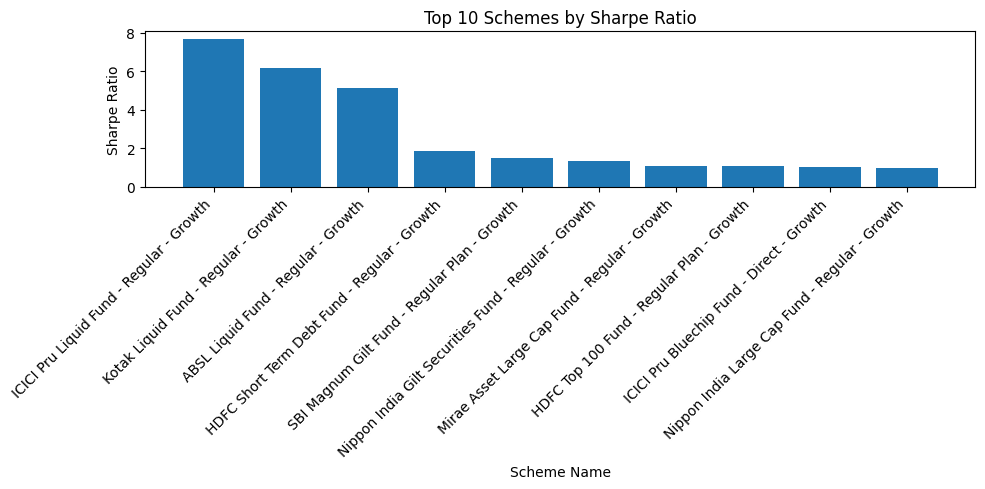

In [11]:
import matplotlib.pyplot as plt

# Top 10 schemes based on Sharpe ratio
top_schemes = df.sort_values("sharpe_ratio", ascending=False).head(10)

plt.figure(figsize=(10,5))

plt.bar(top_schemes["scheme_name"], top_schemes["sharpe_ratio"])

plt.title("Top 10 Schemes by Sharpe Ratio")
plt.xlabel("Scheme Name")
plt.ylabel("Sharpe Ratio")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig("rolling_sharpe_chart.png")
plt.show()

In [14]:
# =========================
# STEP 6: COHORT PROXY ANALYSIS
# =========================

cohort = df.groupby("category").agg(
    avg_return_1yr=("return_1yr_pct", "mean"),
    avg_return_3yr=("return_3yr_pct", "mean"),
    avg_sharpe=("sharpe_ratio", "mean"),
    avg_beta=("beta", "mean"),
    avg_aum=("aum_crore", "mean"),
    scheme_count=("scheme_name", "count")
).reset_index()

cohort.to_csv("cohort_analysis.csv", index=False)

cohort

,category,avg_return_1yr,avg_return_3yr,avg_sharpe,avg_beta,avg_aum,scheme_count
0,ELSS,11.160000,13.580000,0.800000,0.980000,2989.000000,1
1,Flexi Cap,16.585000,15.495000,0.970000,0.975000,26462.000000,2
2,Gilt,5.765000,5.690000,1.425000,0.295000,27065.500000,2
3,Index,13.760000,12.100000,0.930000,0.900000,7350.000000,1
4,Index/ETF,10.140000,11.770000,0.910000,1.040000,20284.000000,1
5,Large & Mid Cap,14.910000,14.560000,0.910000,0.990000,49046.000000,1
6,Large Cap,13.724286,12.985714,0.927857,0.942857,23176.142857,14
7,Liquid,6.443333,6.333333,6.333333,0.386667,35244.666667,3
8,Mid Cap,15.978571,16.590000,0.871429,0.978571,28426.285714,7
9,Short Duration,6.830000,7.370000,1.840000,0.440000,27953.000000,1


In [15]:
# =========================
# STEP 7: SIP CONTINUITY PROXY ANALYSIS
# =========================

# We simulate "continuity" using risk stability metrics

sip_proxy = df.groupby("scheme_name").agg(
    avg_return=("return_3yr_pct", "mean"),
    volatility=("std_dev_ann_pct", "mean"),
    max_drawdown=("max_drawdown_pct", "mean"),
    sharpe=("sharpe_ratio", "mean")
).reset_index()

# Define stability score (higher = more consistent)
sip_proxy["stability_score"] = (
    sip_proxy["sharpe"] - sip_proxy["volatility"]/100 - abs(sip_proxy["max_drawdown"])/100
)

# Sort best stable schemes
sip_proxy = sip_proxy.sort_values("stability_score", ascending=False)

# Save output
sip_proxy.to_csv("sip_continuity.csv", index=False)

sip_proxy.head()

,scheme_name,avg_return,volatility,max_drawdown,sharpe,stability_score
17,ICICI Pru Liquid Fund - Regular - Growth,7.68,0.5,-2.62,7.68,7.6488
23,Kotak Liquid Fund - Regular - Growth,6.18,0.5,-3.81,6.18,6.1369
1,ABSL Liquid Fund - Regular - Growth,5.14,0.5,-3.66,5.14,5.0984
12,HDFC Short Term Debt Fund - Regular - Growth,7.37,4.0,-6.01,1.84,1.7399
34,SBI Magnum Gilt Fund - Regular Plan - Growth,6.07,4.0,-2.30,1.52,1.4570


In [16]:
# =========================
# STEP 8: FUND RECOMMENDATION ENGINE
# =========================

def recommend_funds(risk_level):

    df_clean = df.copy()

    # LOW RISK
    if risk_level == "Low":
        filtered = df_clean[df_clean["beta"] < 0.8]

    # MODERATE RISK
    elif risk_level == "Moderate":
        filtered = df_clean[(df_clean["beta"] >= 0.8) & (df_clean["beta"] <= 1.2)]

    # HIGH RISK
    elif risk_level == "High":
        filtered = df_clean[df_clean["beta"] > 1.2]

    else:
        return "Invalid risk level"

    # Rank by best Sharpe + return
    filtered["score"] = filtered["sharpe_ratio"] + filtered["return_3yr_pct"]

    top_3 = filtered.sort_values("score", ascending=False).head(3)

    return top_3[["scheme_name", "category", "beta", "sharpe_ratio", "return_3yr_pct"]]


# Example usage (you can change this)
recommend_funds("Moderate")

C:\Users\VIJAYAKUMARI\AppData\Local\Temp\ipykernel_5148\704891566.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered["score"] = filtered["sharpe_ratio"] + filtered["return_3yr_pct"]


,scheme_name,category,beta,sharpe_ratio,return_3yr_pct
2,SBI Small Cap Fund - Regular Plan - Growth,Small Cap,0.89,0.94,23.39
3,SBI Small Cap Fund - Direct Plan - Growth,Small Cap,1.04,0.93,23.14
29,ABSL Small Cap Fund - Regular - Growth,Small Cap,0.97,0.90,22.38


In [17]:
# =========================
# STEP 9: HHI CONCENTRATION ANALYSIS
# =========================

import numpy as np
import matplotlib.pyplot as plt

# Step 1: Count schemes per category
sector_counts = df["category"].value_counts().reset_index()
sector_counts.columns = ["category", "count"]

# Step 2: Market share
sector_counts["market_share"] = sector_counts["count"] / sector_counts["count"].sum()

# Step 3: HHI calculation
sector_counts["hhi_component"] = sector_counts["market_share"] ** 2
hhi_total = sector_counts["hhi_component"].sum()

print("Total HHI Index:", hhi_total)

# Save CSV
sector_counts.to_csv("sector_hhi.csv", index=False)

sector_counts

Total HHI Index: 0.18999999999999992


,category,count,market_share,hhi_component
0,Large Cap,14,0.350,0.122500
1,Mid Cap,7,0.175,0.030625
2,Small Cap,6,0.150,0.022500
3,Liquid,3,0.075,0.005625
4,Gilt,2,0.050,0.002500
5,Flexi Cap,2,0.050,0.002500
6,Value,1,0.025,0.000625
7,Short Duration,1,0.025,0.000625
8,Index/ETF,1,0.025,0.000625
9,Index,1,0.025,0.000625


In [18]:
# =========================
# STEP 10: ADVANCED ANALYTICS SUMMARY
# =========================

print("===== ADVANCED ANALYTICS SUMMARY =====\n")

# 1. VaR / CVaR insight
print("1. Risk Analysis (VaR & CVaR)")
print("- Measures worst-case loss and extreme downside risk across schemes.\n")

# 2. Sharpe ratio insight
print("2. Risk-Adjusted Performance (Sharpe Ratio)")
print("- Identifies schemes providing best return per unit of risk.\n")

# 3. Cohort analysis insight
print("3. Cohort / Category Behavior")
print("- Categories show different return-risk profiles and fund concentration.\n")

# 4. SIP continuity insight (proxy)
print("4. Investment Stability (Proxy SIP Analysis)")
print("- Measures consistency using volatility, drawdown, and Sharpe ratio.\n")

# 5. Recommendation system
print("5. Fund Recommendation Engine")
print("- Suggests funds based on risk appetite using beta and performance score.\n")

# 6. HHI analysis
print("6. Sector Concentration Risk (HHI)")
print("- Shows diversification level across categories.\n")

print("===== END OF DAY 6 ANALYTICS =====")

===== ADVANCED ANALYTICS SUMMARY =====

1. Risk Analysis (VaR & CVaR)
- Measures worst-case loss and extreme downside risk across schemes.

2. Risk-Adjusted Performance (Sharpe Ratio)
- Identifies schemes providing best return per unit of risk.

3. Cohort / Category Behavior
- Categories show different return-risk profiles and fund concentration.

4. Investment Stability (Proxy SIP Analysis)
- Measures consistency using volatility, drawdown, and Sharpe ratio.

5. Fund Recommendation Engine
- Suggests funds based on risk appetite using beta and performance score.

6. Sector Concentration Risk (HHI)
- Shows diversification level across categories.

===== END OF DAY 6 ANALYTICS =====
